# QASMTrans Demo
This notebook mirrors the `python/demo.py` script but walks through the workflow step by step without helper functions.


In [1]:
from __future__ import annotations

import json
from pathlib import Path
from tempfile import NamedTemporaryFile

from IPython.display import Image, display
import qasmtrans as qt  # type: ignore
import qasmtrans.plot_pulses as plot_pulses  # type: ignore


def find_repo_root(start: Path) -> Path:
    base = start if start.is_dir() else start.parent
    for candidate in [base, *base.parents]:
        if (candidate / "pyproject.toml").exists():
            return candidate
    raise RuntimeError("Cannot locate project root containing pyproject.toml")


START_PATH = Path(__file__).resolve() if "__file__" in globals() else Path.cwd()
REPO = find_repo_root(START_PATH)
print(f"Project root: {REPO}")


Project root: /Users/hoyt924/Library/CloudStorage/OneDrive-PNNL/Documents/qasmtrans


## 1. Transpile the benchmark circuit from file
Configure the transpiler to read `adder_n4.qasm` and target the IBMQ Toronto backend configuration shipped with the repo.


In [2]:
qasm_path = REPO / "data" / "test_benchmark" / "adder_n4.qasm"
backend_path = REPO / "data" / "devices" / "ibmq_toronto.json"

opts_file = qt.TranspileOptions()
opts_file.backend_config = str(backend_path)
opts_file.output_path = str(REPO / "data" / "output_demo")
opts_file.verbose = 1
opts_file.disable_mapomatic = False
opts_file.mapomatic_limit = 200

result_file = qt.transpile_qasm(str(qasm_path), opts_file)
print("Log:", result_file.log)
print("Output QASM path:", result_file.output_qasm_path)
print("Preview:")
for line in result_file.output_qasm.splitlines()[:8]:
    print("    " + line)


Log: Transpiled adder_n4.qasm with mode=ibmq, qubits=4
STEP-1. Initial gate decomposition time: 0.037109ms
STEP-2. Routing and mapping time: 0.071045ms
Calibration-aware heuristic (critical path fidelity): best 0.947642, worst 0.619863
Log-fidelity spread: 4.245e-01
Critical path aggregation: log product
Mapomatic timing (ms): critical-path prep 0.000, embedding 0.058, scoring 0.132, apply 0.027
Critical path latency: 0.000004 s
Mapomatic evaluated 105 candidate mapping(s).
STEP-3. Calibration-aware optimization time: 0.244873ms
STEP-4. Basis gate decomposition time: 0.030029ms
 total QASMTrans time: 0.138184ms
Transpiled circuit contains 11 qubits and 37 basis gates: cx:16, rz:11, sx:4, x:6, 

Output QASM path: /Users/hoyt924/Library/CloudStorage/OneDrive-PNNL/Documents/qasmtrans/data/output_demo
Preview:
    OPENQASM 2.0;
    include "qelib1.inc";
    qreg q[11];
    creg c[4];
    x q[5]; 
    sx q[5]; 
    rz(-1.5708) q[5]; 
    sx q[5]; 


## 2. Transpile directly from a raw QASM string
Read the same benchmark circuit into memory to highlight how string inputs can be passed directly without touching the filesystem.


In [3]:
qasm_text = qasm_path.read_text()

opts_string = qt.TranspileOptions()
opts_string.backend_config = str(backend_path)
opts_string.output_path = str(REPO / "data" / "output_demo_string")
opts_string.disable_mapomatic = True
opts_string.verbose = 0

result_string = qt.transpile_qasm(qasm_text, opts_string)
print("Log:", result_string.log)
print("QASM length:", len(result_string.output_qasm))


Log: Transpiled qasmtrans_input_23469_640978391222958.qasm with mode=ibmq, qubits=4
QASM length: 745


## 3. Build a minimal backend + pulse template and plot the resulting pulses
Create lightweight backend/pulse JSON payloads on the fly, transpile a two-qubit program, and emit a pulse plot.


Log: Transpiled qasmtrans_input_23469_640979234145208.qasm with mode=ibmq, qubits=2
Pulse JSON path: /Users/hoyt924/Library/CloudStorage/OneDrive-PNNL/Documents/qasmtrans/data/output_demo_pulses_pulses.json


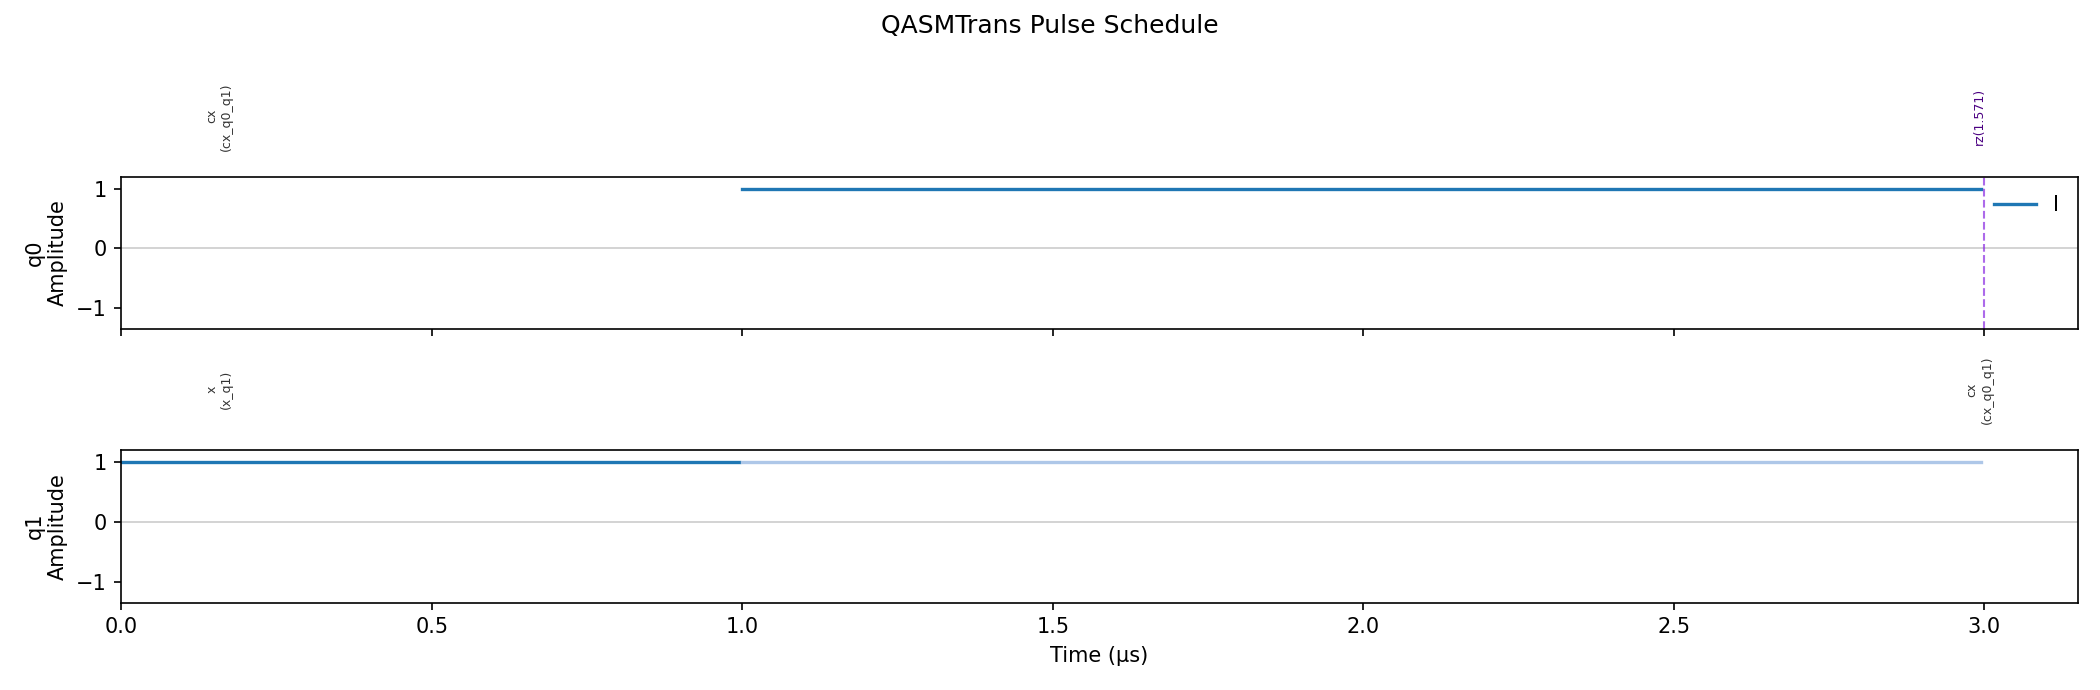

In [4]:
qasm_demo = """OPENQASM 2.0;
include "qelib1.inc";
qreg q[2];
creg c[2];
x q[0];
cx q[0],q[1];
rz(1.5708) q[1];
measure q[0] -> c[0];
measure q[1] -> c[1];
"""

backend_doc = {
    "name": "demo_backend",
    "version": "0.1",
    "num_qubits": 2,
    "basis_gates": ["x", "rz", "cx"],
    "gate_lens": {"x0": 1.0, "x1": 1.0, "rz0": 0.0, "rz1": 0.0, "cx0_1": 2.0},
    "gate_errs": {"x0": 0.0, "x1": 0.0, "rz0": 0.0, "rz1": 0.0, "cx0_1": 0.0},
    "cx_coupling": ["0_1"],
}

template_doc = {
    "name": "demo_template",
    "version": "0.1",
    "pulse_definitions": [
        {"id": "rz_q0", "gate": "rz", "qubits": [0], "shape": "virtual", "waveform_type": "virtual", "width": 0.0, "amplitude": 0.0, "virtual": True},
        {"id": "rz_q1", "gate": "rz", "qubits": [1], "shape": "virtual", "waveform_type": "virtual", "width": 0.0, "amplitude": 0.0, "virtual": True},
        {"id": "x_q0", "gate": "x", "qubits": [0], "shape": "const", "waveform_type": "const", "width": 1e-6, "amplitude": 1.0},
        {"id": "x_q1", "gate": "x", "qubits": [1], "shape": "const", "waveform_type": "const", "width": 1e-6, "amplitude": 1.0},
        {"id": "cx_q0_q1", "gate": "cx", "qubits": [0, 1], "shape": "const", "waveform_type": "const", "width": 2e-6, "amplitude": 1.0},
    ],
}

backend_tmp = NamedTemporaryFile("w", suffix=".json", delete=False)
template_tmp = NamedTemporaryFile("w", suffix=".json", delete=False)
backend_tmp_path = Path(backend_tmp.name)
template_tmp_path = Path(template_tmp.name)
backend_tmp.close()
template_tmp.close()
backend_tmp_path.write_text(json.dumps(backend_doc, indent=2))
template_tmp_path.write_text(json.dumps(template_doc, indent=2))

try:
    opts = qt.TranspileOptions()
    opts.backend_config = str(backend_tmp_path)
    opts.pulse_template_path = str(template_tmp_path)
    opts.output_path = str(REPO / "data" / "output_demo_pulses")
    opts.limited_qubits = True

    result_pulses = qt.transpile_qasm(qasm_demo, opts)
    print("Log:", result_pulses.log)
    print("Pulse JSON path:", result_pulses.pulse_path)

    pulse_doc = result_pulses.pulse_doc if result_pulses.pulse_doc is not None else json.loads(result_pulses.pulse_schedule or "{}")
    analog_events, virtual_events, labels = plot_pulses.build_qubit_events(pulse_doc)

    with NamedTemporaryFile("wb", suffix=".png", delete=False) as tmp_plot:
        plot_path = Path(tmp_plot.name)
    try:
        plot_pulses.plot_events(
            analog_events_by_qubit=analog_events,
            virtual_events_by_qubit=virtual_events,
            label_sequences=labels,
            title="QASMTrans Pulse Schedule",
            output_path=plot_path,
            dpi=150,
            samples_per_us=200.0,
        )
        display(Image(filename=str(plot_path)))
    finally:
        plot_path.unlink(missing_ok=True)
finally:
    backend_tmp_path.unlink(missing_ok=True)
    template_tmp_path.unlink(missing_ok=True)


All steps complete. Adjust the cells above as needed to target other benchmarks or hardware descriptions.
